In [2]:
from herbie import Herbie, FastHerbie
import pandas as pd, numpy as np
import xarray as xr
import dask
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt


In [3]:
#seting the run time
run = pd.Timestamp("2026-04-13-12")
run


Timestamp('2026-04-13 12:00:00')

In [4]:
#finding the run
H = FastHerbie([run], model="hrrr", product="sfc", fxx=np.arange(0,49,1).tolist(), save_dir='./data/', overwrite=True)
H

In [5]:
#selecting the products
ss = r"(CAPE:255-0 mb above ground|REFC:entire atmosphere|VIL:entire atmosphere|DZDT:0.5-0.8|RETOP:cloud top)"
H.inventory(ss)

/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expre

,grib_message,start_byte,end_byte,range,reference_time,valid_time,variable,level,forecast_time,search_this,FILE
0,1,0,445619.0,0-445619,2026-04-13 12:00:00,2026-04-13 12:00:00,REFC,entire atmosphere,anl,:REFC:entire atmosphere:anl,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
1,2,445620,711910.0,445620-711910,2026-04-13 12:00:00,2026-04-13 12:00:00,RETOP,cloud top,anl,:RETOP:cloud top:anl,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
2,4,1311928,1801104.0,1311928-1801104,2026-04-13 12:00:00,2026-04-13 12:00:00,VIL,entire atmosphere,anl,:VIL:entire atmosphere:anl,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
3,40,25601912,25786164.0,25601912-25786164,2026-04-13 12:00:00,2026-04-13 12:00:00,DZDT,0.5-0.8 sigma layer,0-0 day ave fcst,:DZDT:0.5-0.8 sigma layer:0-0 day ave fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
4,154,122650812,123246225.0,122650812-123246225,2026-04-13 12:00:00,2026-04-13 12:00:00,CAPE,255-0 mb above ground,anl,:CAPE:255-0 mb above ground:anl,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
...,...,...,...,...,...,...,...,...,...,...,...
240,1,0,758575.0,0-758575,2026-04-13 12:00:00,2026-04-15 12:00:00,REFC,entire atmosphere,48 hour fcst,:REFC:entire atmosphere:48 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
241,2,758576,1070834.0,758576-1070834,2026-04-13 12:00:00,2026-04-15 12:00:00,RETOP,cloud top,48 hour fcst,:RETOP:cloud top:48 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
242,4,2048033,2622411.0,2048033-2622411,2026-04-13 12:00:00,2026-04-15 12:00:00,VIL,entire atmosphere,48 hour fcst,:VIL:entire atmosphere:48 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
243,40,29886927,30531775.0,29886927-30531775,2026-04-13 12:00:00,2026-04-15 12:00:00,DZDT,0.5-0.8 sigma layer,47-48 hour ave fcst,:DZDT:0.5-0.8 sigma layer:47-48 hour ave fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...


In [6]:
filepath = H.download(ss)

/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expre

In [7]:
#opening the dataset
ds = xr.open_mfdataset(filepath, combine='nested', concat_dim='valid_time')

/tmp/ipykernel_575601/3373317245.py:2: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds = xr.open_mfdataset(filepath, combine='nested', concat_dim='valid_time')


In [8]:
#sorting the dataset by time
ds = ds.sortby('valid_time')

In [9]:
#selecting area of interest
ds_sub = ds.sel(y=slice(100,750), x=slice(600,1550))

In [10]:
#turning it into a netcdf
fname = f'hrrr_{run:%Y%m%d%H}.nc'
ds_sub.to_netcdf(fname)

In [11]:
#opening the netcdf
ds_final = xr.open_dataset(fname)
ds_final

sh: 1: getfattr: not found


<xarray.Dataset> Size: 615MB
Dimensions:                  (valid_time: 49, y: 650, x: 950)
Coordinates:
  * valid_time               (valid_time) datetime64[ns] 392B 2026-04-13T12:0...
    time                     datetime64[ns] 8B ...
    step                     (valid_time) timedelta64[ns] 392B ...
    atmosphere               float64 8B ...
    latitude                 (y, x) float64 5MB ...
    longitude                (y, x) float64 5MB ...
    cloudTop                 float64 8B ...
    sigmaLayer               float64 8B ...
    pressureFromGroundLayer  float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    refc                     (valid_time, y, x) float32 121MB ...
    unknown                  (valid_time, y, x) float32 121MB ...
    veril                    (valid_time, y, x) float32 121MB ...
    wz                       (valid_time, y, x) float32 121MB ...
    cape                     (valid_time, y, x) float32 121MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-04-13T17:01 GRIB to CDM+CF via cfgrib-0.9.1...

In [12]:
#removing the uknown
ds_final = ds_final.rename({"unknown":"cloudtop"})
ds_final

<xarray.Dataset> Size: 615MB
Dimensions:                  (valid_time: 49, y: 650, x: 950)
Coordinates:
  * valid_time               (valid_time) datetime64[ns] 392B 2026-04-13T12:0...
    time                     datetime64[ns] 8B ...
    step                     (valid_time) timedelta64[ns] 392B ...
    atmosphere               float64 8B ...
    latitude                 (y, x) float64 5MB ...
    longitude                (y, x) float64 5MB ...
    cloudTop                 float64 8B ...
    sigmaLayer               float64 8B ...
    pressureFromGroundLayer  float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    refc                     (valid_time, y, x) float32 121MB ...
    cloudtop                 (valid_time, y, x) float32 121MB ...
    veril                    (valid_time, y, x) float32 121MB ...
    wz                       (valid_time, y, x) float32 121MB ...
    cape                     (valid_time, y, x) float32 121MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-04-13T17:01 GRIB to CDM+CF via cfgrib-0.9.1...

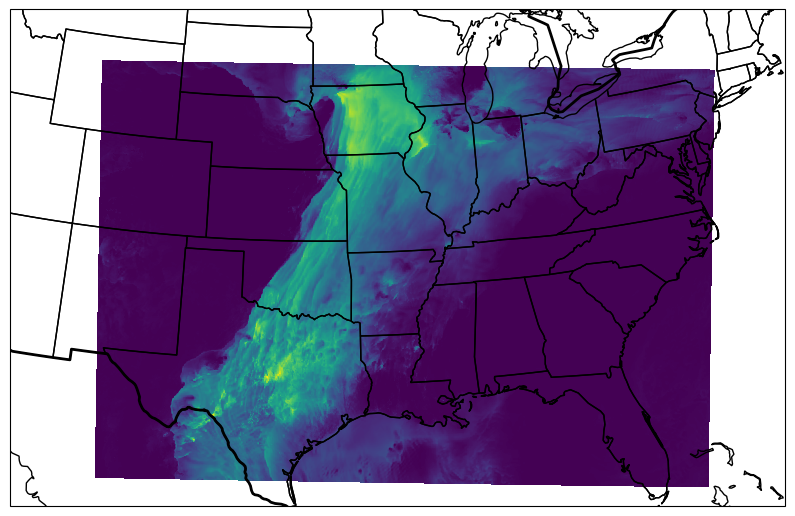

In [13]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection=ccrs.LambertConformal())

#ax.stock_img()

ax.add_feature(cfeature.COASTLINE)

ax.add_feature(cfeature.BORDERS, linewidth=2)
ax.add_feature(cfeature.STATES)
ax.pcolormesh(ds_final.longitude, ds_final.latitude, ds_final.cape.isel(valid_time=12), transform = ccrs.PlateCarree())
ax.set_extent([-110, -75, 25, 45])

In [14]:
#5 hour rolling products
refc_5hr_rolling = ds_final["refc"].rolling(valid_time=5).max()
cape_5hr_rolling = ds_final["cape"].rolling(valid_time=5).max()
wz_5hr_rolling = ds_final["wz"].rolling(valid_time=5).max()
veril_5hr_rolling = ds_final["veril"].rolling(valid_time=5).max()
#derived products
vil_density =  (ds_final["veril"] /  ds_final["cloudtop"]) 
vil_density_5hr_rolling = vil_density.rolling(valid_time=5).max()

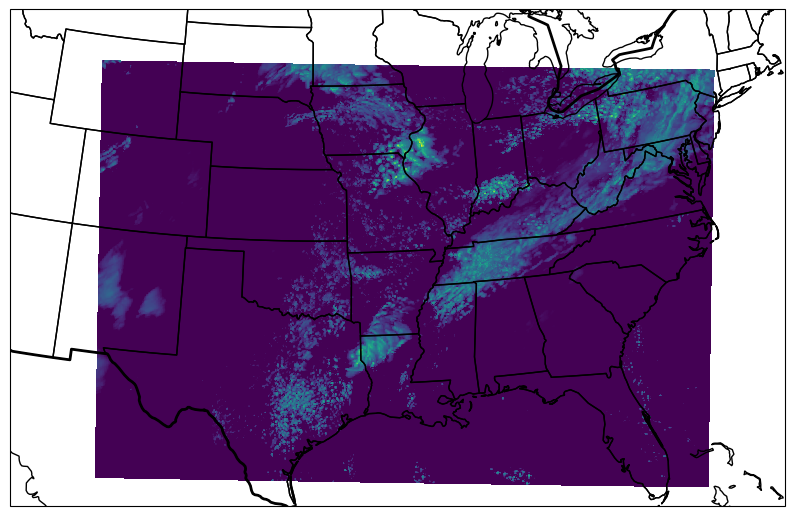

In [15]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection=ccrs.LambertConformal())

#ax.stock_img()

ax.add_feature(cfeature.COASTLINE)

ax.add_feature(cfeature.BORDERS, linewidth=2)
ax.add_feature(cfeature.STATES)
ax.pcolormesh(ds_final.longitude, ds_final.latitude, refc_5hr_rolling.isel(valid_time=5), transform = ccrs.PlateCarree())
ax.set_extent([-110, -75, 25, 45])

In [22]:
ds2_file = xr.open_dataset("hrrr_2026041312.nc") # ds_file used to open the netcdf file for us to use the data to create plots
ds2_file
ds2_file = ds2_file.rename({"unknown":"cloudtop"})

sh: 1: getfattr: not found


In [23]:
#5 hour rolling products
refc_5hr_rolling = ds2_file["refc"].rolling(valid_time=5).max()
cape_5hr_rolling = ds2_file["cape"].rolling(valid_time=5).max()
wz_5hr_rolling = ds2_file["wz"].rolling(valid_time=5).max()
veril_5hr_rolling = ds2_file["veril"].rolling(valid_time=5).max()
#derived products
vil_density =  (ds2_file["veril"] /  ds2_file["cloudtop"]) *100
vil_density_5hr_rolling = vil_density.rolling(valid_time=5).max()

In [24]:
import cartopy.feature as cfeature
def map(): #map function used to create our base maps when needed
    fig = plt.figure(figsize=(12,9)) #figure size for us to place our base map
    ax = fig.add_subplot(111, projection=ccrs.LambertConformal()) #projection used for our base map
    ax.set_extent([-107,-79,26,44], ccrs.PlateCarree()) #set extent for our base map to zoom into our area of interest
    ax.add_feature(cfeature.COASTLINE) #coastlines added on our map 
    ax.add_feature(cfeature.STATES, linestyle=':')
    ax.add_feature(cfeature.BORDERS)
    return fig, ax
lon = ds2_file['longitude'] #getting the longitude from our ds_file so we can plot our data
lat = ds2_file['latitude'] #gettting the latitude from our ds_file so we can plot our data
dataproj = ccrs.PlateCarree() #making PlateCarree in our dataproj so we can add it to our pcolormesh

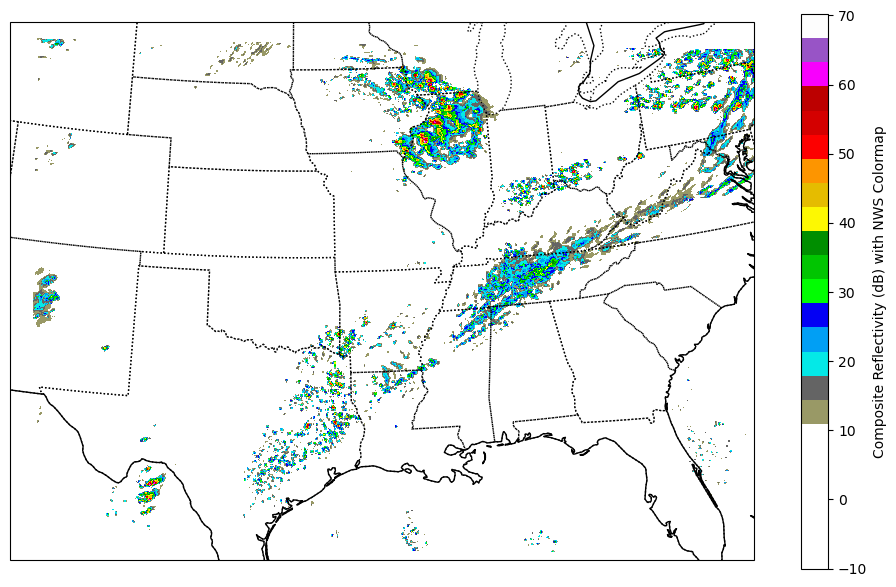

In [25]:
# Custom Colormap of Composite Reflectivity worked on by Jonathan
from matplotlib.colors import ListedColormap #Importing module to use to generate custom colormap

# Colormap found on notebook.community, using the NWS's color scheme for composite reflectivity
nws_reflectivity_colors = [ 
    "#FFFFFF", # ND
    "#FFFFFF", # -30
    "#FFFFFF", # -25
    "#FFFFFF", # -20
    "#FFFFFF", # -15
    "#FFFFFF", # -10
    "#999966", # -5
    "#646464", # 0
    "#04e9e7", # 5
    "#019ff4", # 10
    "#0300f4", # 15
    "#02fd02", # 20
    "#01c501", # 25
    "#008e00", # 30
    "#fdf802", # 35
    "#e5bc00", # 40
    "#fd9500", # 45
    "#fd0000", # 50
    "#d40000", # 55
    "#bc0000", # 60
    "#f800fd", # 65
    "#9854c6", # 70
    "#fdfdfd" # 75
    ]

# Converting the colormap to a usable object to plot
nws_cmap = ListedColormap(nws_reflectivity_colors, name='nws_reflectivity_colors')

fig,ax=map() # Calling and printing the base map function created above

# Creating a colormesh plot of 5-hour max composite reflectivity liquid plotted on longitude and latitude, valid at 03Z, using the custom colormap
custom_colormap = ax.pcolormesh(ds2_file.longitude, ds2_file.latitude, refc_5hr_rolling.isel(valid_time=8), cmap = nws_cmap, transform = ccrs.PlateCarree()) 
# Creating a vertically oriented colorbar of 5-hour max composite reflectivity, using the custom colormap
plt.colorbar(custom_colormap, ax=ax, label = 'Composite Reflectivity (dB) with NWS Colormap', shrink = 0.8) #creating a colorbar for our map and shrinking it to a respectable size
# Creating title containing information about content, initial time, and valid time of the plot

plt.show() # Display the map

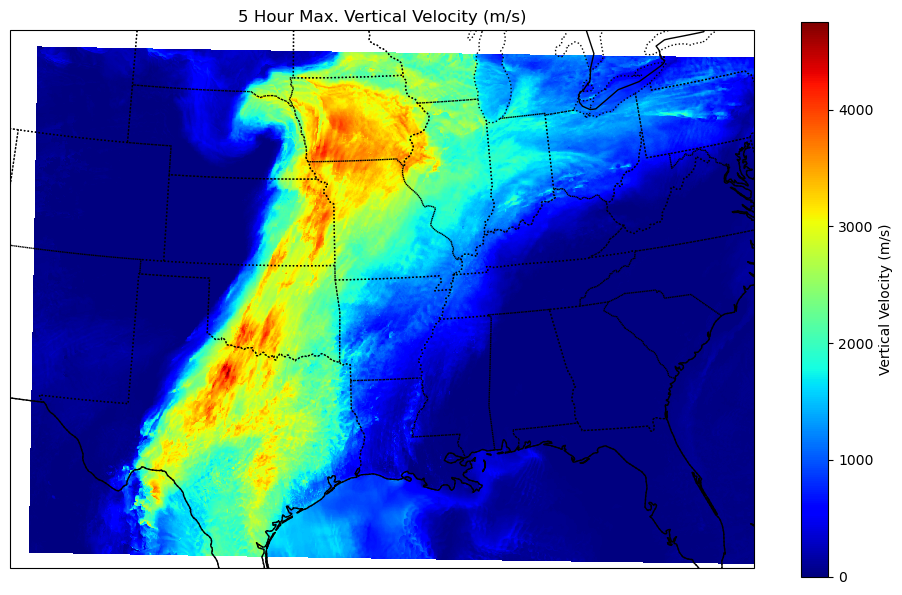

In [26]:
#Plot 2: Vertical Velocity worked on by Jonathan

wz_5hr_rolling = ds2_file["wz"].rolling(valid_time=5).max() #Extracting the 5-hour max vertical velocity from the data file so it can be plotted

fig,ax=map() # Calling and printing the base map function created above

# Creating a colormesh plot of 5-hour max vertical velocity plotted on longitude and latitude, valid at 03Z
vert_velocity = ax.pcolormesh(ds2_file.longitude, ds2_file.latitude, cape_5hr_rolling.isel(valid_time=8), cmap = 'jet', transform=ccrs.PlateCarree())

cbar = plt.colorbar(vert_velocity, ax=ax, orientation='vertical', pad=0.05, shrink=0.8) # Creating a vertically oriented colorbar of 5-hour max vertical velocity
cbar.set_label('Vertical Velocity (m/s)') # Labeling colorbar with title and units

# Creating title containing information about content, initial time, and valid time of the plot
plt.title(f'5 Hour Max. Vertical Velocity (m/s)')

plt.show() # Display the map

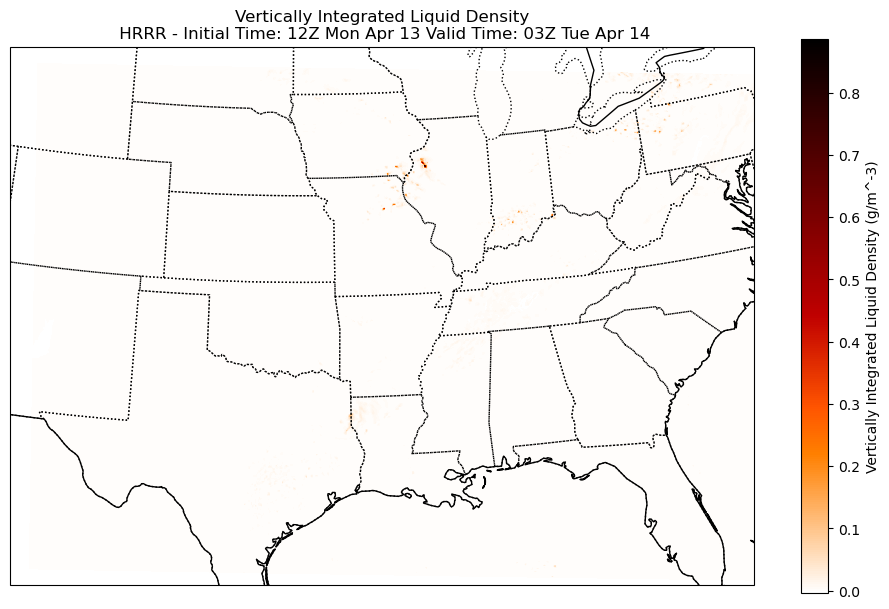

In [27]:
fig, ax = map() #printing out the base map funtion we created above
pcolor = ax.pcolormesh(lon, lat, vil_density_5hr_rolling.isel(valid_time=5), cmap = 'gist_heat_r', transform =ccrs.PlateCarree()) #creating the pcolor mesh with the valid_time of 15 with the color map of gist heat in reverse and adding longitude and latitude.
plt.colorbar(pcolor, ax=ax, label = 'Vertically Integrated Liquid Density (g/m^-3)', shrink = 0.8) #creating a colorbar for our map and shrinking it to a respectable size
ax.set_title(f"Vertically Integrated Liquid Density\n HRRR - Initial Time: {pd.to_datetime(ds2_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds2_file['valid_time'].isel(valid_time=15).values):%HZ %a %b %d}") #setting our title with the model type, initial time, valid time, and what it is plotting
plt.show() # Display the map

In [28]:

# Start with all contributions set to 0
vil_density_5hr_rolling_time =vil_density_5hr_rolling.isel(valid_time=5).values
vil_density_contribution = np.zeros_like(vil_density_5hr_rolling_time)


mask = (vil_density_5hr_rolling_time >= 0.25) & (vil_density_5hr_rolling_time < 1.75 )
vil_density_contribution[mask] = (vil_density_5hr_rolling_time[mask] - 0.25) / 1.50




mask = (vil_density_5hr_rolling_time >= 1.75) 
vil_density_contribution[mask] = 1.0


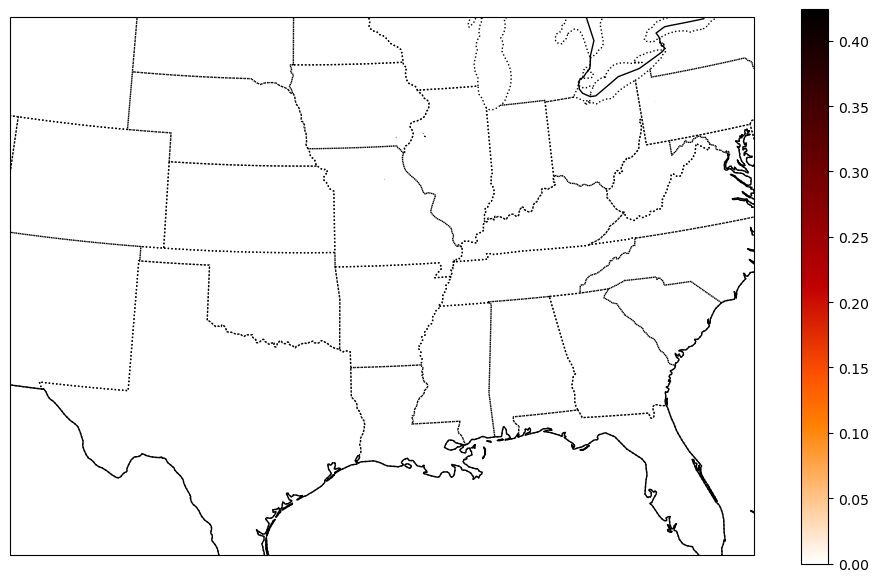

In [29]:
fig, ax = map() #printing out the base map funtion we created above
pcolor = ax.pcolormesh(lon, lat, vil_density_contribution, cmap = 'gist_heat_r', transform =ccrs.PlateCarree()) #creating the pcolor mesh with the valid_time of 15 with the color map of gist heat in reverse and adding longitude and latitude.
plt.colorbar(pcolor, ax=ax, shrink = 0.8)

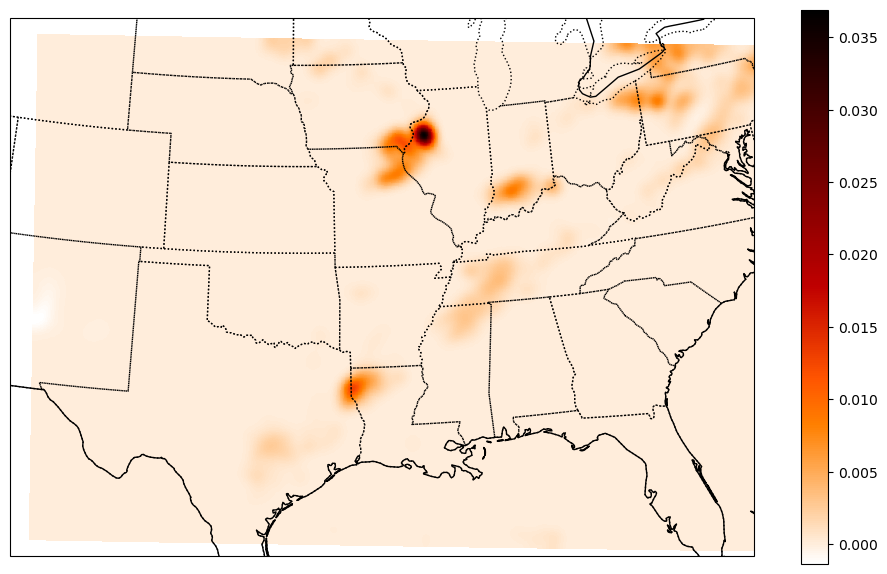

In [30]:
import metpy.calc as mpcalc
vil_density_5hr_rolling_time_smooth = mpcalc.smooth_gaussian(vil_density_5hr_rolling_time, 50)

fig, ax = map() #printing out the base map funtion we created above
pcolor = ax.pcolormesh(lon, lat, vil_density_5hr_rolling_time_smooth, cmap = 'gist_heat_r', transform =ccrs.PlateCarree()) #creating the pcolor mesh with the valid_time of 15 with the color map of gist heat in reverse and adding longitude and latitude.
plt.colorbar(pcolor, ax=ax, shrink = 0.8)

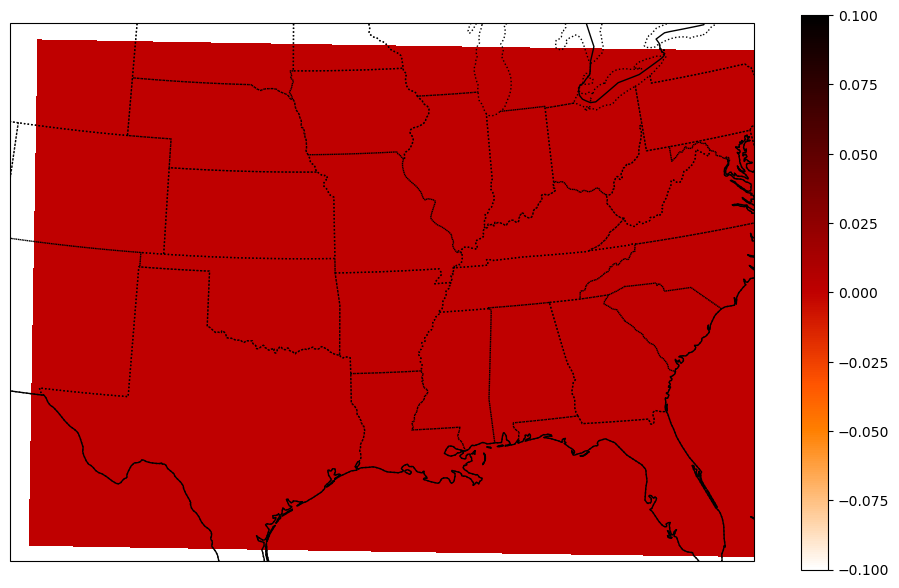

In [31]:
vil_density_contribution_smooth = np.zeros_like(vil_density_5hr_rolling_time_smooth)


mask = (vil_density_5hr_rolling_time_smooth >= 0.06) & (vil_density_5hr_rolling_time_smooth < 0.12 )
vil_density_contribution_smooth[mask] = (vil_density_5hr_rolling_time_smooth[mask] - 0.06) / 0.06




mask = (vil_density_5hr_rolling_time_smooth >= 0.12) 
vil_density_contribution_smooth[mask] = 1.0


fig, ax = map() #printing out the base map funtion we created above
pcolor = ax.pcolormesh(lon, lat, vil_density_contribution_smooth, cmap = 'gist_heat_r', transform =ccrs.PlateCarree()) #creating the pcolor mesh with the valid_time of 15 with the color map of gist heat in reverse and adding longitude and latitude.
plt.colorbar(pcolor, ax=ax, shrink = 0.8)


In [32]:
#Code for testing the algorithm on additional events worked on by Manuel
ds_highend_file = xr.open_dataset("hrrr_2026041312.nc") #ds_highend_file used to open the netcdf file for us to plot the second high end case
ds_highend_file = ds_highend_file.rename({"unknown":"cloudtop"}) #cloudtops shows up as unknown and renaming it makes the data set easier to work with

#5 hour rolling products for the high-end case
refc_5hr_rolling_highend = ds_highend_file["refc"].rolling(valid_time=5).max()
cape_5hr_rolling_highend = ds_highend_file["cape"].rolling(valid_time=5).max()
vert_velo_5hr_rolling_highend = ds_highend_file["wz"].rolling(valid_time=5).max()
veril_5hr_rolling_highend =ds_highend_file["veril"].rolling(valid_time=5).max()
#derived products for high end
vil_density_highend =  (ds_highend_file["veril"] /  ds_highend_file["cloudtop"]) *100
vil_density_5hr_rolling_highend = vil_density_highend.rolling(valid_time=5).max()

sh: 1: getfattr: not found


In [39]:
#making the individual indecies for the high end case
# Start with all contributions set to 0 for vil density
vil_density_5hr_rolling_highend_time = vil_density_5hr_rolling_highend.isel(valid_time=14).values
vil_density_contribution_highend = np.zeros_like(vil_density_5hr_rolling_highend_time)


mask = (vil_density_5hr_rolling_highend_time >= 0.25) & (vil_density_5hr_rolling_highend_time < 1.75 )
vil_density_contribution_highend[mask] = (vil_density_5hr_rolling_highend_time[mask] - 0.25) / 1.50

mask = (vil_density_5hr_rolling_highend_time >= 1.75) 
vil_density_contribution_highend[mask] = 1

#refc index
refc_5hr_rolling_highend_time = refc_5hr_rolling_highend.isel(valid_time=14).values
refc_contribution_highend = np.zeros_like(refc_5hr_rolling_highend_time)

# Setting the index = 0 if reflectivity is less than 45 
mask = refc_5hr_rolling_highend_time < 45
refc_contribution_highend[mask] = 0

# Creating a linearly increasing index from 0 to 1, for reflectivity in betwene 45 and 60 (inclusive)
mask = (refc_5hr_rolling_highend_time >= 45) & (refc_5hr_rolling_highend_time <= 60)
refc_contribution_highend[mask] = ((refc_5hr_rolling_highend_time[mask] - 45) / 15)

# Setting the index = 1 if reflectivty is greater than 60
mask = refc_5hr_rolling_highend_time > 60
refc_contribution_highend[mask] = 1

#cape index
cape_5hr_rolling_highend_time = cape_5hr_rolling_highend.isel(valid_time=14).values
cape_contribution_highend = np.zeros_like(cape_5hr_rolling_highend_time)

# Setting the index = 0 if CAPE is less than 1250
mask = (cape_5hr_rolling_highend_time < 1250)
cape_contribution_highend[mask] = 0

# Creating a linearly increasing index from 0 to 1, for CAPE in between 1250 and 2500 (inclusive)
mask = (cape_5hr_rolling_highend_time >= 1250) & (cape_5hr_rolling_highend_time <= 2500)
cape_contribution_highend[mask] = (cape_5hr_rolling_highend_time[mask] - 1250) / 1250

# Setting the index = 1 if CAPE is greater than 2500
mask = cape_5hr_rolling_highend_time > 2500
cape_contribution_highend[mask] = 1

#vertical velocity parameter index
vert_velo_5hr_rolling_highend_time = vert_velo_5hr_rolling_highend.isel(valid_time=14).values
vert_velo_contribution_highend = np.zeros_like(vert_velo_5hr_rolling_highend_time)

mask = (vert_velo_5hr_rolling_highend_time >= 0) & (vert_velo_5hr_rolling_highend_time < 0.55)
vert_velo_contribution_highend[mask] = (vert_velo_5hr_rolling_highend_time[mask] - 0) / 1.45

mask = (vert_velo_5hr_rolling_highend_time >= 0.55) & (vert_velo_5hr_rolling_highend_time < 1.2)
vert_velo_contribution_highend[mask] = (vert_velo_5hr_rolling_highend_time[mask] - 0.20) / 1

mask = (vert_velo_5hr_rolling_highend_time >= 1.2)
vert_velo_contribution_highend[mask] = 1

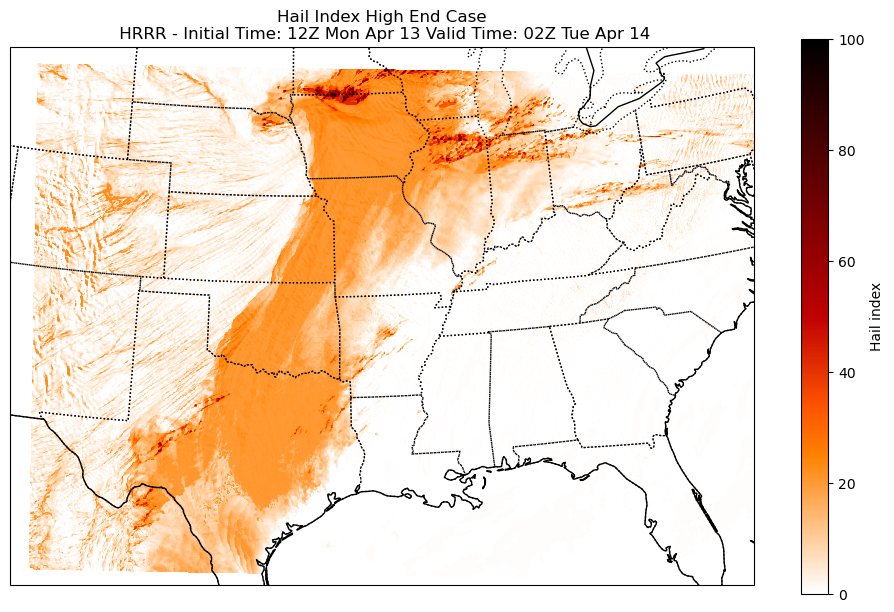

In [40]:
#making the hail index 
def hail_index_highend():
    hail_index_calc_highend = (cape_contribution_highend * 0.20 + refc_contribution_highend * 0.225 + vil_density_contribution_highend * .35 + vert_velo_contribution_highend * 0.225) * 100
    return hail_index_calc_highend

hail_index_highend()

#plotting the high end case
fig, ax = map() #printing out the base map funtion we created above
pcolor = ax.pcolormesh(lon, lat, hail_index_highend(), cmap = 'gist_heat_r' ,vmax = 100, transform =ccrs.PlateCarree()) #creating the pcolor mesh with the valid_time of 15 with the color map of gist heat in reverse and adding longitude and latitude.
plt.colorbar(pcolor, ax=ax, label = 'Hail index', shrink = 0.8) #creating a colorbar for our map and shrinking it to a respectable size
ax.set_title(f"Hail Index High End Case\n HRRR - Initial Time: {pd.to_datetime(ds_highend_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_highend_file['valid_time'].isel(valid_time=14).values):%HZ %a %b %d}") #setting our title with the model type, initial time, valid time, and what it is plotting
plt.show() # Display the map